# TRAITEMENT DU SIGNAL DE MESURE DES VAGUES

## importation des bibliothèques et Chargement des données

In [1]:
# Traitement Spectral des données ADCP
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, filtfilt 
from scipy.signal import welch
from scipy.interpolate import interp1d
from datetime import datetime, timedelta
import pandas as pd

# Configuration globale
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['American Typewriter']
plt.rcParams.update({'font.size': 14}) # Taille de base pour tout

# Chargement des données ADCP
# Equivalent de load('Dikwe_StEvette_LEG1.mat')
data = loadmat('/Users/arnoldkono/Desktop/waves.mat')
Burst_Time = data['Burst_Time'].flatten()
Burst_AltimeterDistanceAST = data['Burst_AltimeterDistanceAST'].flatten()

## Gestion du format du temps des données

In [2]:
 Burst_Time # Visualisation du format du temps

array([738909.50000073, 738909.50000218, 738909.50000362, ...,
       738952.56949292, 738952.56949436, 738952.56949581])

In [3]:
# Conversion des datenum en datetime
temps = pd.to_datetime(Burst_Time - 719529, unit='D')

# 719529 est le décalage (offset) entre l'origine MATLAB (0000-01-01)
# et l'origine pandas (1970-01-01).

## Visualisation des séries temporelles brutes

Text(0.5, 1.0, 'Série temporelle brute')

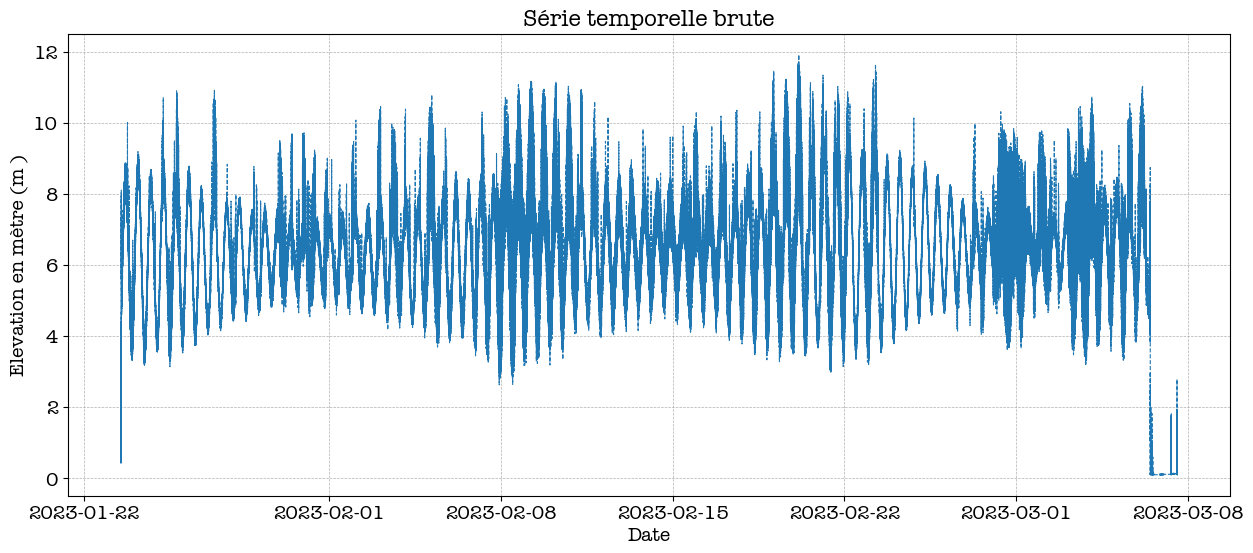

In [4]:

# Visualisation des élévations de l'ADCP (optionnel)
plt.figure(figsize=(15,6))
plt.plot( temps ,Burst_AltimeterDistanceAST , linestyle='--', linewidth=0.8,)
plt.ylabel('Elevation en mètre (m )')
plt.xlabel('Date')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.title('Série temporelle brute', )

## Création du DataFrame et vérification des trous

In [5]:
df = pd.DataFrame({
    'temps': temps,
    'eta': Burst_AltimeterDistanceAST })

df.head()

,temps,eta
0,2023-01-23 12:00:00.062995034,2.169700
1,2023-01-23 12:00:00.187999384,2.159688
2,2023-01-23 12:00:00.312993676,2.162663
3,2023-01-23 12:00:00.438008083,2.162673
4,2023-01-23 12:00:00.562992318,2.158217


In [6]:
#Compter les valeurs d'élévation maquantes dans la série
df['eta'].isna().sum()

np.int64(0)

Text(0.5, 1.0, 'Graphe de calcul de différence entre les pas de temps consécutifs')

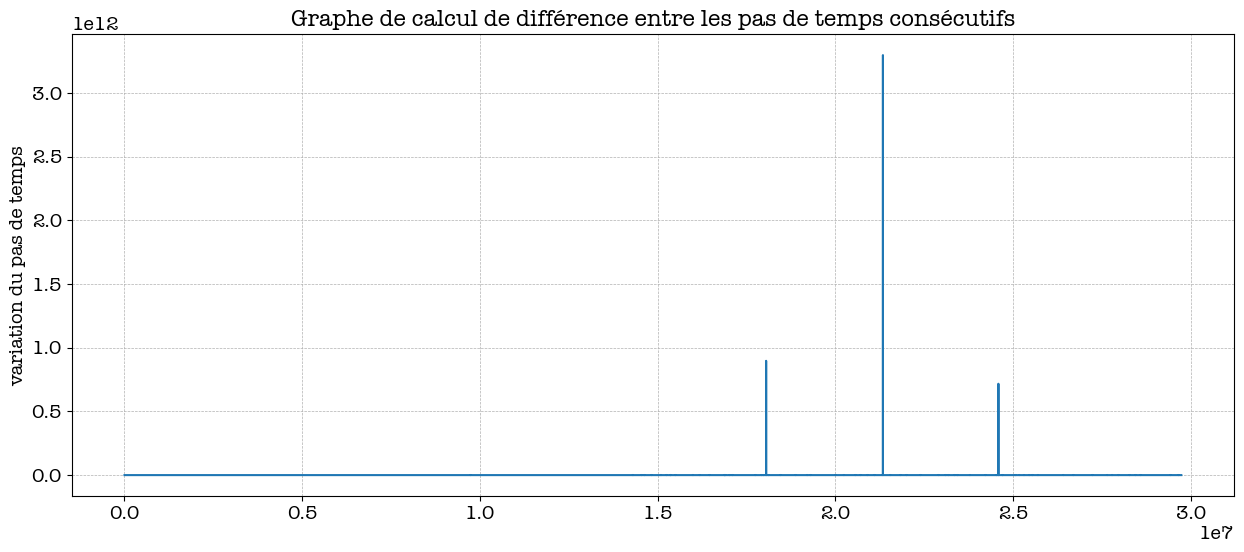

In [7]:
#On calcule et on affiche la difference entre les pas de temps consecutifs pour vérifier si le pas de temps est constant tout au long de la mesure
dt = np.diff(df['temps'])

plt.figure(figsize=(15, 6))
plt.plot(dt)
plt.ylabel('variation du pas de temps')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.title("Graphe de calcul de différence entre les pas de temps consécutifs")

## Création de la nouvelle grille temporelle à pas de temps constant

In [8]:
# créer un nouveau data frame avec toutes les dates sans trous qui servira de nouvelle base temporelle 
start = pd.to_datetime(Burst_Time [0] - 719529, unit='D') # le debut qui correspond au premier datenum comverti en datetime
end = pd.to_datetime(Burst_Time [-1] - 719529, unit='D') # la fin qui correspond au dernier datenum comverti en datetime
delta = pd.to_timedelta( 1/8 , unit= 's') # le pas de temps ou on converti la fréqucece 8Hz en milisecondes

#On crée l'intervalle de date qui servira de niuvelle base  temporelle
df2 = pd.date_range(
    start=start, 
    end=end, 
    freq=delta )

#On crée le nouveau dataframe
dodo = pd.DataFrame (
    {'temps': df2 } )

In [9]:
#On calcule le nombre de lignes qui étaient vides
print (len(df['temps']) - len(dodo['temps']))

-40003


In [10]:
#On crée le nouveau dataframe qui a les dates sans trous et qui affecte nan aux lignes de la colone elevation oû il n'y avait pas de date au départ 
yo = pd.merge(df, dodo, on='temps', how='outer')
yo.tail()

,temps,eta
59471846,2023-03-07 13:40:04.188002275,0.111240
59471847,2023-03-07 13:40:04.312995034,NaN
59471848,2023-03-07 13:40:04.312996567,1.271030
59471849,2023-03-07 13:40:04.437995034,NaN
59471850,2023-03-07 13:40:04.438000917,1.164581


In [11]:
#On procède à l'interpolattion des valeurs pour avoir une serie continue de valeurs
yo['eta']=yo['eta'].interpolate(method='spline', order =2)
yo.tail()

,temps,eta
59471846,2023-03-07 13:40:04.188002275,0.111240
59471847,2023-03-07 13:40:04.312995034,-0.035376
59471848,2023-03-07 13:40:04.312996567,1.271030
59471849,2023-03-07 13:40:04.437995034,-0.035380
59471850,2023-03-07 13:40:04.438000917,1.164581


## On centre le signal en soustrayant la moyenne

In [12]:
# Centrage du signal (soustraction de la moyenne)
yo['eta_cent'] = yo['eta'] - np.mean(yo['eta'])

## Gestion des variations aberrantes

In [13]:
eto= yo['eta_cent'].to_numpy()
tmp= yo['temps'].to_numpy()

# Conversion sécurisée de tmp en numérique
if not np.issubdtype(tmp.dtype, np.number):
    # Conversion en nanosecondes (entiers)
    tmp_numeric = pd.to_datetime(tmp).view(np.int64).astype(float)
else:
    tmp_numeric = tmp.astype(float)

seuil = 0.125
niter = 20

for kiter in range(niter):
    diff_etd = np.abs(np.diff(eto))
    ind = np.where(diff_etd < seuil)[0]
    
    if len(ind) > 1:
        # On utilise maintenant des nombres (float) pour X et Y
        f_interp = interp1d(tmp_numeric[ind], eto[ind], 
                            kind='linear', fill_value='extrapolate')
        eto = f_interp(tmp_numeric)
    else:
        break

yo['eta_cent_R'] = pd.DataFrame(eto)

Text(0.5, 1.0, 'Courbe avec variations lissées')

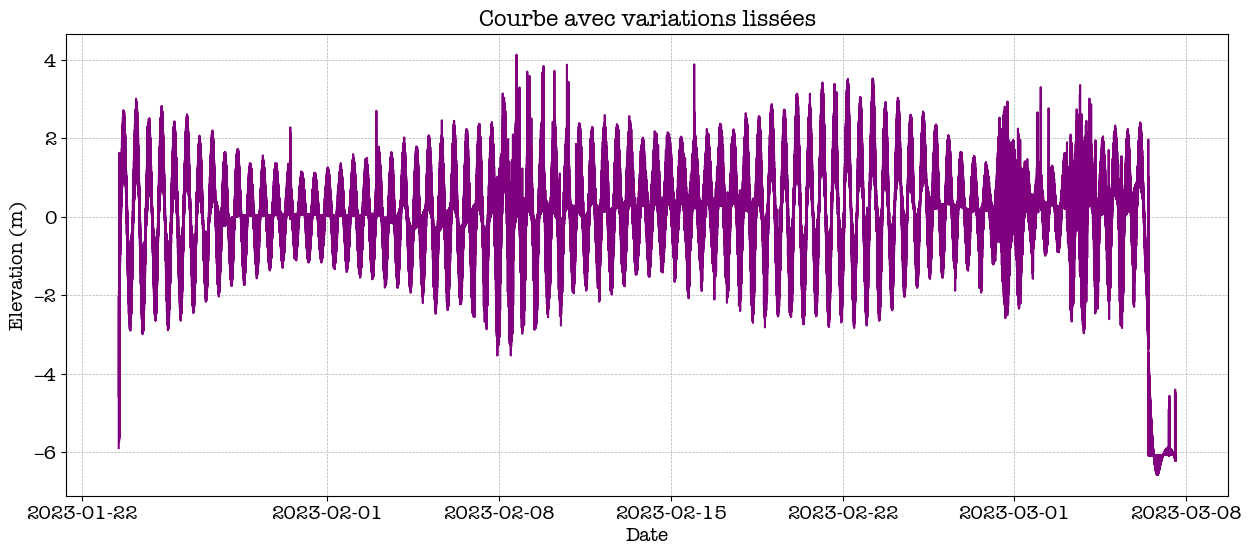

In [14]:
plt.figure(figsize=(15,6))
plt.plot (tmp,eto , color ='purple')
plt.ylabel('Elevation (m)')
plt.xlabel('Date')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.title('Courbe avec variations lissées')

### Filtrage du bruit et séparation des phénomènes à l'aide du filtre de BUTTERWORTH

In [15]:
#Filtrage du Signal

# --- Paramètres d'échantillonnage ---
frech = 8.0               # Fréquence d'échantillonnage (Hz)
fmaree = 1/12/60/60       # Fréquence de la marée (~12h)
nyq = frech / 2           # Fréquence de Nyquist

# --- 1. Filtre du bruit ---
ordfi = 4
fcoup = 1.0
cutoff_lp1 = fcoup / nyq
bb1, ba1 = butter(ordfi, cutoff_lp1, btype='low')
yo['et1'] = filtfilt(bb1, ba1, yo['eta_cent_R'])

# --- 2. Filtre Très Basse Fréquence ( Marée ) ---
cutoff_lp2 = (fmaree * 50) / nyq
bb2, ba2 = butter(ordfi, cutoff_lp2, btype='low')
yo['et2'] = filtfilt(bb2, ba2, yo['eta_cent_R'])

# --- 3. Filtre Passe-Bande ( Vagues ) ---
cutoff_bp = [(fmaree * 50) / nyq, fcoup / nyq]
bb3, ba3 = butter(ordfi, cutoff_bp, btype='bandpass')
yo['et3'] = filtfilt(bb3, ba3, yo['eta_cent_R'])

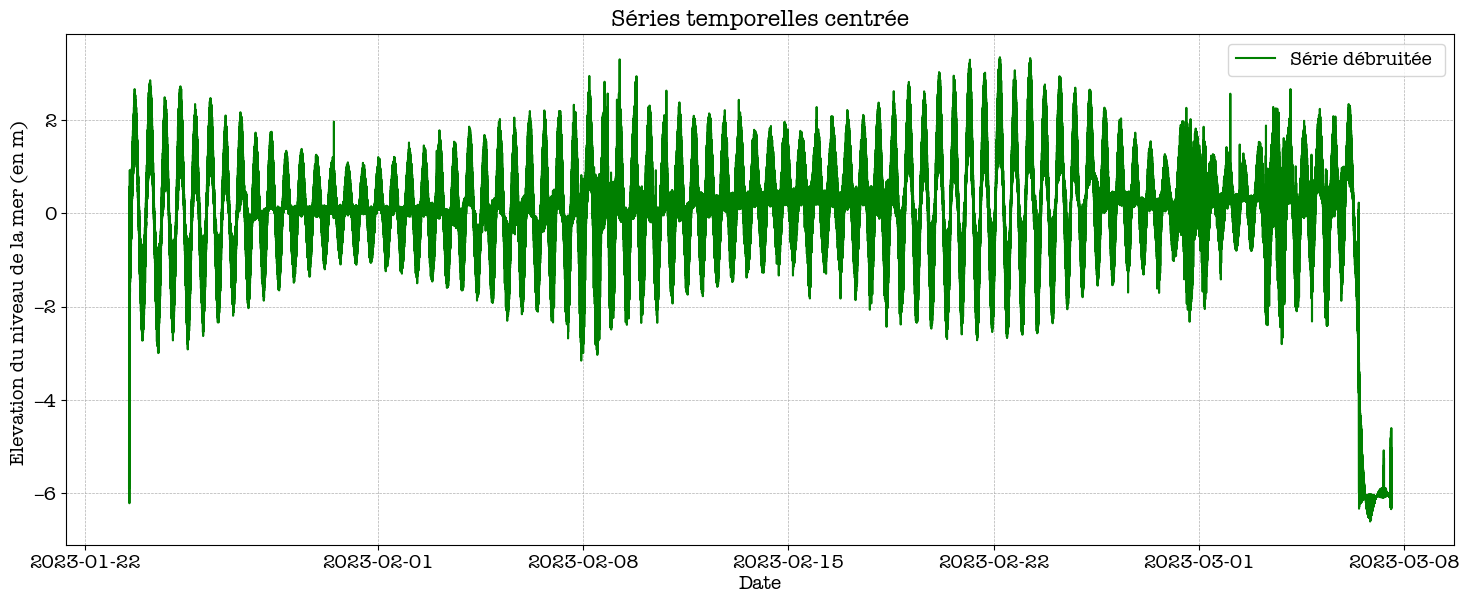

In [21]:
#Affichage des series temporelles
plt.figure(figsize=(15, 6))
plt.plot( yo['temps'],yo['et1'] , label='Série débruitée ', color='green' , linewidth=1.5)

plt.ylabel('Elevation du niveau de la mer (en m) ')
plt.xlabel('Date')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.title("Séries temporelles centrée")
plt.legend() # Affiche la légende pour distinguer les courbes
plt.show()

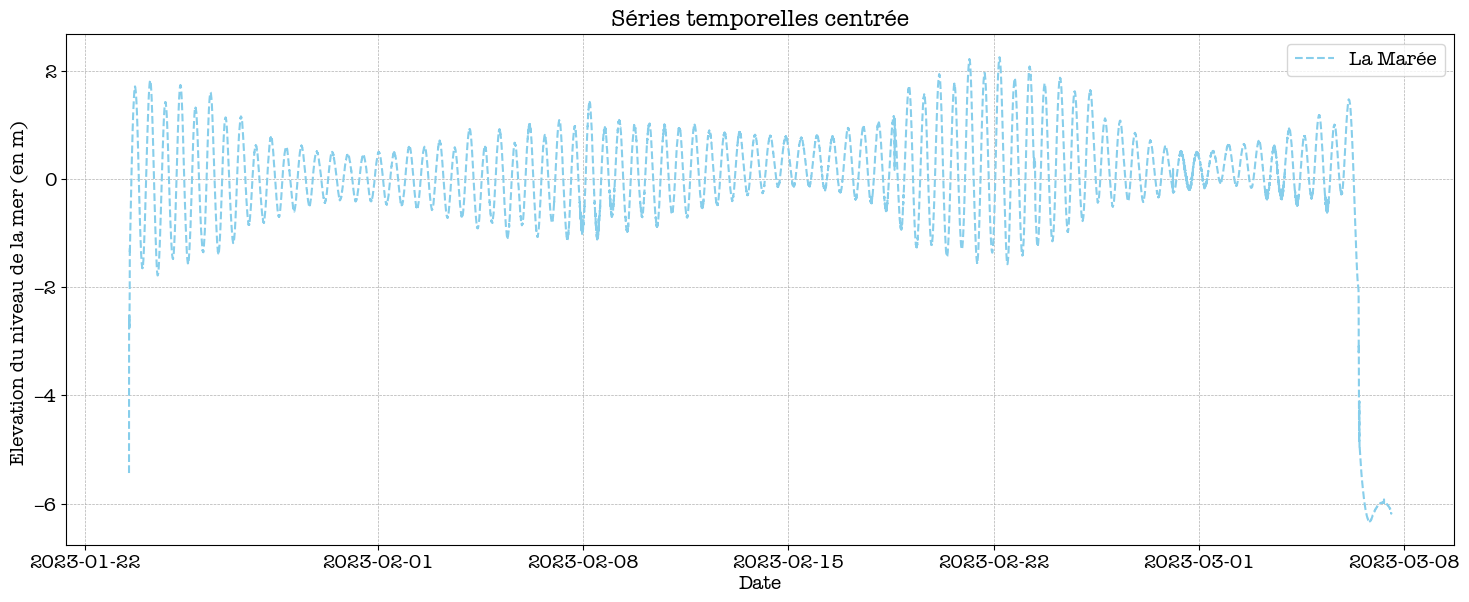

In [18]:
#Affichage des series temporelles
plt.figure(figsize=(15, 6))
plt.plot( yo['temps'],yo['et2'] , label='La Marée', color='skyblue', linestyle='--' , linewidth=1.5)
plt.ylabel('Elevation du niveau de la mer (en m) ')
plt.xlabel('Date')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.title("Séries temporelles centrée")
plt.legend() # Affiche la légende pour distinguer les courbes
plt.show()

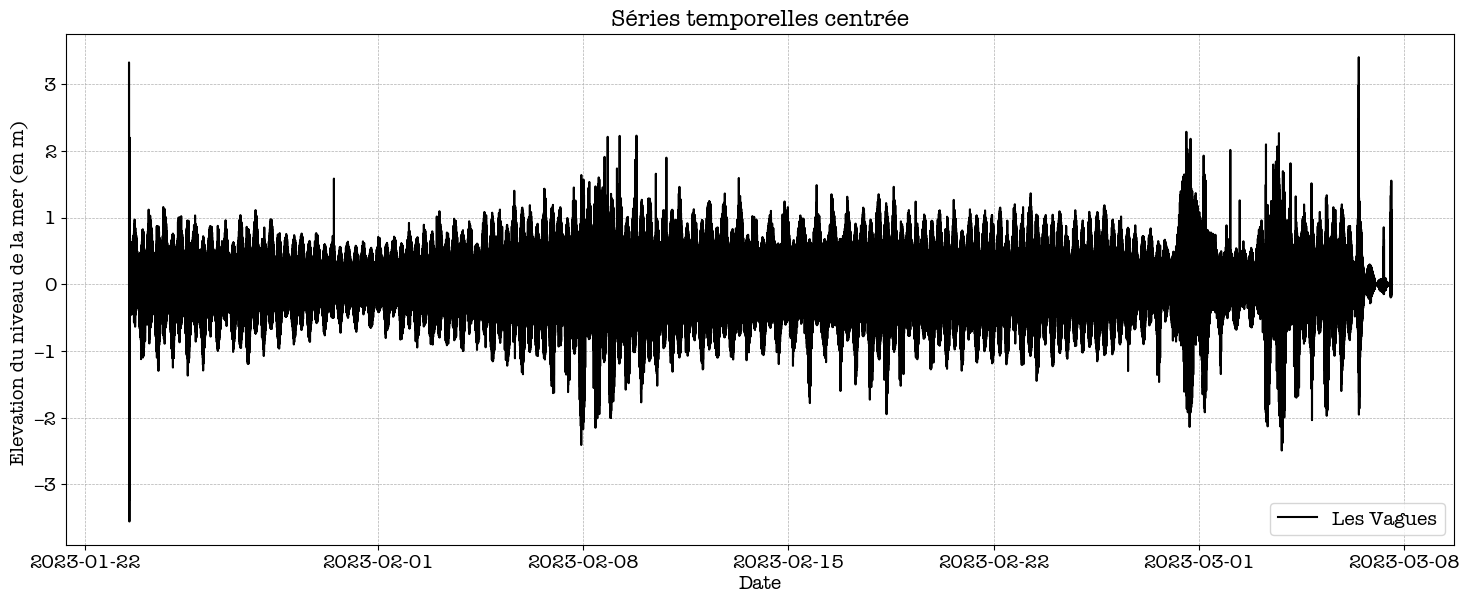

In [20]:
#Affichage des series temporelles
plt.figure(figsize=(15, 6))
plt.plot( yo['temps'],yo['et3'] , label='Les Vagues', color='k' , linewidth=1.5)

plt.ylabel('Elevation du niveau de la mer (en m) ')
plt.xlabel('Date')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.title("Séries temporelles centrée")
plt.legend() # Affiche la légende pour distinguer les courbes
plt.show()

## Analyse Spectrale par la methode de welch

In [82]:
#Analyse spectrale 
fs= 8 #Hz
fen = 60* 60  #fenetre considérée pour le calcul
pts =   (fen*fs) 

# Listes pour stocker les résultats 
HS = []
FP = []  # Liste pour la fréquence pic
time_steps = []

# Boucle de calcul
for i in range(0, len(yo['eta']), pts):
    segment = yo['eta_cent'][i : i + pts]


    # Calcul du spectre de puissance
    freqs, power_spec = welch(segment, fs=fs, nperseg=pts, noverlap=0)

    # 1. Calcul de la fréquence pic (fp)
    # On cherche l'indice où la puissance est maximale
    idx_peak = np.argmax(power_spec)
    fp = freqs[idx_peak]
    
    # 2. Calcul du moment d'ordre zéro (m0)
    m0 = np.trapz(power_spec, freqs)
    
    # 3. Calcul de Hs
    hs = 4 * np.sqrt(m0)

    # Stockage
    HS.append(hs)
    FP.append(fp)
    time_steps.append(yo['temps'][i])

caract=  pd.DataFrame (
    {'time': time_steps ,
     'HS': HS,
     'fp' : FP
     
      } )

/var/folders/ly/hkyyspm15rd1pjjzbf956_cw0000gn/T/ipykernel_1245/2445515787.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  m0 = np.trapz(power_spec, freqs)
/Users/arnoldkono/Library/Python/3.9/lib/python/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 28800 is greater than input length  = 28651, using nperseg = 28651
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


<Figure size 1200x600 with 0 Axes>

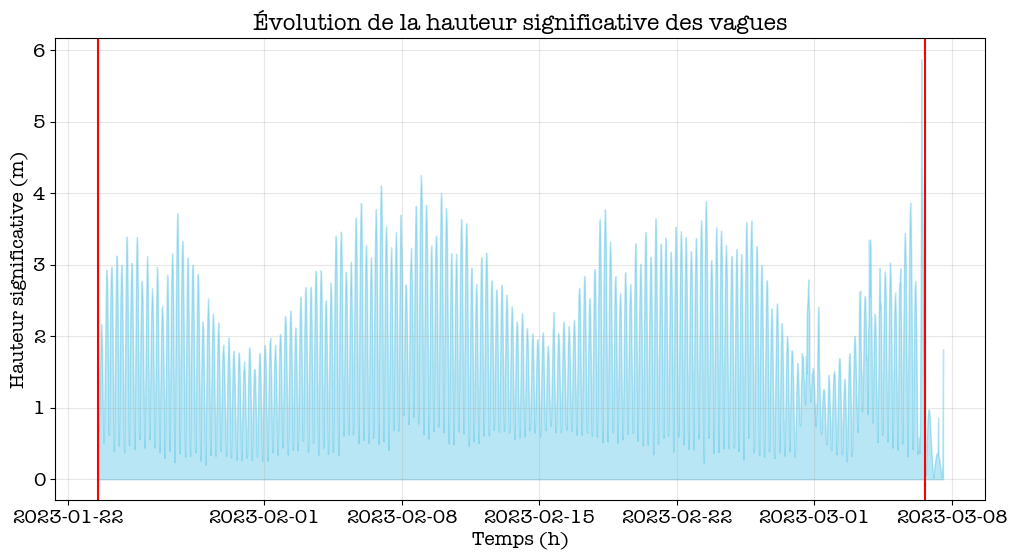

In [94]:
plt.figure(figsize=(12,6))
#plt.plot(caract ['time'], caract ['HS'] , color="#76291a", linewidth=1, label='Hs')
plt.figure(figsize=(12, 6))
#plt.plot(time_steps, HS, )
plt.fill_between(time_steps, HS, alpha=0.3, color="#1aafdd")
plt.xlabel('Temps (h)')
plt.ylabel('Hauteur significative (m)')

plt.axvline(x=caract['time'][2], color='r', linestyle='-')
plt.axvline(x=caract['time'][2020], color='r', linestyle='-')

plt.title('Évolution de la hauteur significative des vagues')
plt.grid(True, alpha=0.3)